# Loan Management System: with Human-in-the-loop using langgraph + ollama

## The Problem: RBI Loan Department is Overwhelmed

The **Reserve Bank of India's loan department** processes **hundreds of loan applications every day**. Each application must be:

- **Verified** — KYC documents, income proof, employment status
- **Credit-checked** — CIBIL score, repayment history, existing loans
- **Fraud-screened** — anomalous patterns, fake documents, identity mismatch
- **Risk-assessed** — Debt-to-Income ratio, collateral, sector risk
- **Compliance-checked** — RBI norms, FEMA rules, KYC guidelines

The current process is broken:

| Problem | Impact |
|---------|--------|
| Manual review of every document | 5-7 days processing time |
| Different officers apply different criteria | Inconsistent approvals |
| Fraud slips through manual checks | Financial losses |
| Senior officers spend time on routine low-risk loans | Bottleneck |
| No audit trail for decisions | Compliance risk |

> **The Solution:** AI agents handle the routine screening, analysis, and risk tiering automatically. Humans only step in at critical decision points — exactly where judgment matters most.

## How HITL Works in LangGraph

LangGraph provides `interrupt()` — a function that **pauses** the entire agent workflow and waits for a human response.

```
AI agents analyse loan...
        │
        ▼
┌─────────────────────┐
│    interrupt()      │ ◄── Workflow PAUSES here
│  "High-risk loan    │     Shows details to officer
│   ₹5 lakh for       │
│   new business.     │
│   Approve?"         │
└─────────┬───────────┘
          │
    Officer reviews
    and decides
          │
          ▼
┌─────────────────────┐
│  Command(resume=    │ ◄── Human decision
│   "approved")       │     sent back
└─────────┬───────────┘
          │
          ▼
Workflow resumes...
```

The paused workflow uses **zero compute** while waiting. LangGraph saves the entire state via its **checkpointing system** — the agent can wait minutes, hours, or days and resume exactly where it left off.

## Our Loan Approval Workflow

```
Application Submitted
        │
        ▼
┌──────────────────┐
│  Loan Analyser   │ ◄── Ollama LLM: checks documents, credit, fraud, risk
└────────┬─────────┘
         │
    ┌────┴────┐
    │  Risk?  │
    └────┬────┘
         │
   ┌─────┴───────┐
   │             │
   ▼             ▼
LOW RISK      HIGH RISK
(auto)        (needs human)
   │             │
   │         ┌───┴──────┐
   │         │ PAUSE    │
   │         │interrupt │ ◄── Loan Officer Reviews
   │         └───┬──────┘
   │             │
   ▼             ▼
┌──────────────────────┐
│  Process Decision    │
└──────────────────────┘
         │
         ▼
┌──────────────────────┐
│  Audit Logger        │ ◄── Saves full trace for RBI compliance
└──────────────────────┘
         │
         ▼
       END
```

## Step 1: Setup Ollama

In [20]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.2",
    base_url = "http://localhost:11434",
    temperature=0
)
# Quick test
test = llm.invoke("Reply with only: Ollama connected")
print("LLM Status:", test.content)

## Step 2: Create the Loan Applications Database

- **Low-risk loans** → AI auto-approves (no human needed)
- **High-risk loans** → AI screens → Human officer reviews
- **Fraud-flagged loans** → AI flags → Human investigates

In [3]:
LOAN_DB = {
    "LOAN-001": {
        "applicant": "Priya Sharma",
        "age": 32,
        "occupation": "Software Engineer",
        "monthly_income": 85000,
        "loan_amount": 300000,        # ₹3 lakh
        "loan_type": "personal",
        "purpose": "Home renovation",
        "cibil_score": 780,
        "existing_emi": 5000,
        "employment_years": 6,
        "collateral": None,
        "status": "pending",
    },
    "LOAN-002": {
        "applicant": "Rajesh Verma",
        "age": 45,
        "occupation": "Business Owner",
        "monthly_income": 250000,
        "loan_amount": 5000000,       # ₹50 lakh
        "loan_type": "business",
        "purpose": "Business expansion into new markets",
        "cibil_score": 690,
        "existing_emi": 45000,
        "employment_years": 12,
        "collateral": "Commercial property worth ₹80 lakh",
        "status": "pending",
    },
    "LOAN-003": {
        "applicant": "Anil Kumar",
        "age": 28,
        "occupation": "Freelancer",
        "monthly_income": 40000,
        "loan_amount": 2000000,       # ₹20 lakh
        "loan_type": "personal",
        "purpose": "Unknown - applicant gave vague response",
        "cibil_score": 540,
        "existing_emi": 35000,
        "employment_years": 1,
        "collateral": None,
        "status": "pending",
    },
    "LOAN-004": {
        "applicant": "Meena Patel",
        "age": 38,
        "occupation": "Government Employee",
        "monthly_income": 60000,
        "loan_amount": 800000,        # ₹8 lakh
        "loan_type": "home",
        "purpose": "Purchase of residential flat",
        "cibil_score": 740,
        "existing_emi": 8000,
        "employment_years": 10,
        "collateral": "Property being purchased",
        "status": "pending",
    },
}

# RBI Loan Policy Parameters
LOAN_POLICY = {
    "auto_approve_limit": 500000,         # ₹5 lakh → auto-approve if low risk
    "min_cibil_score": 650,               # Minimum CIBIL for any loan
    "max_dti_ratio": 0.50,               # Max Debt-to-Income ratio: 50%
    "high_risk_amount": 2000000,          # ₹20 lakh+ → always needs human review
    "min_employment_years": 1,
}

print("RBI Loan Database loaded!")
print(f"  {len(LOAN_DB)} pending applications")
print(f"  Auto-approve limit: ₹{LOAN_POLICY['auto_approve_limit']:,}")
print(f"  Min CIBIL score:    {LOAN_POLICY['min_cibil_score']}")
print()
for lid, loan in LOAN_DB.items(): # lid-> key, eg:loan-001
    dti = (loan['existing_emi'] / loan['monthly_income']) * 100
    needs_human = (
        loan['amount'] > LOAN_POLICY['auto_approve_limit']
        if 'amount' in loan else
        loan['loan_amount'] > LOAN_POLICY['auto_approve_limit']
    )
    needs_human = loan['loan_amount'] > LOAN_POLICY['auto_approve_limit']
    tag = "[AUTO CANDIDATE]" if not needs_human else "[NEEDS OFFICER]"
    print(f"  {lid}: ₹{loan['loan_amount']:>10,} | CIBIL {loan['cibil_score']} | DTI {dti:.0f}% | {loan['applicant']:<20} {tag}")

RBI Loan Database loaded!
  4 pending applications
  Auto-approve limit: ₹500,000
  Min CIBIL score:    650

  LOAN-001: ₹   300,000 | CIBIL 780 | DTI 6% | Priya Sharma         [AUTO CANDIDATE]
  LOAN-002: ₹ 5,000,000 | CIBIL 690 | DTI 18% | Rajesh Verma         [NEEDS OFFICER]
  LOAN-003: ₹ 2,000,000 | CIBIL 540 | DTI 88% | Anil Kumar           [NEEDS OFFICER]
  LOAN-004: ₹   800,000 | CIBIL 740 | DTI 13% | Meena Patel          [NEEDS OFFICER]


## Step 3: Define graph state

In [4]:
from typing_extensions import TypedDict
from typing import Optional


class LoanState(TypedDict):
    # ── Input ──────────────────────────────────────────────
    loan_id: str                    # Which application we are processing

    # ── Filled by the loan_analyser node ───────────────────
    applicant: str                  # Applicant's name
    loan_amount: float              # Requested loan amount (₹)
    loan_type: str                  # personal / home / business
    cibil_score: int                # CIBIL credit score
    dti_ratio: float                # Debt-to-Income ratio
    fraud_flags: list               # List of fraud/anomaly flags found
    policy_compliant: bool          # Does the loan meet RBI norms?
    risk_level: str                 # "low" | "medium" | "high"
    ai_recommendation: str          # "approve" | "reject" | "review"
    ai_analysis_summary: str        # Human-readable summary by the LLM
    needs_human_review: bool        # Should a loan officer step in?

    # ── Filled by human_review or auto_approve node ────────
    decision: str                   # Final decision: "approved" | "rejected"
    decision_reason: str            # Explanation of the final decision
    reviewed_by: str                # "AI" or officer name

    # ── Audit trail ────────────────────────────────────────
    audit_log: list                 # Full trace of every step taken


print("LoanState defined with", len(LoanState.__annotations__), "fields.")
for field, ftype in LoanState.__annotations__.items():
    print(f"  {field:<25} {str(ftype)}")

LoanState defined with 16 fields.
  loan_id                   <class 'str'>
  applicant                 <class 'str'>
  loan_amount               <class 'float'>
  loan_type                 <class 'str'>
  cibil_score               <class 'int'>
  dti_ratio                 <class 'float'>
  fraud_flags               <class 'list'>
  policy_compliant          <class 'bool'>
  risk_level                <class 'str'>
  ai_recommendation         <class 'str'>
  ai_analysis_summary       <class 'str'>
  needs_human_review        <class 'bool'>
  decision                  <class 'str'>
  decision_reason           <class 'str'>
  reviewed_by               <class 'str'>
  audit_log                 <class 'list'>


## Step 4: Define the graph nodes

Our workflow has four nodes:

| Node | What It Does | Key Feature |
|------|-------------|-------------|
| `loan_analyser` | Uses Ollama LLM to analyse credit, fraud, risk, compliance | The AI brain of the system |
| `human_review` | **Pauses** workflow and asks officer to approve/reject/query | Uses `interrupt()` |
| `auto_approve` | Automatically approves low-risk, policy-compliant loans | No human needed |
| `process_decision` | Records final decision and triggers disbursement | Finalises the loan file |
| `audit_logger` | Saves full trace for RBI compliance audit | Mandatory for banking |

> **The star is `human_review`** — this is where `interrupt()` pauses execution and waits for the loan officer.

In [5]:
from langgraph.types import interrupt
import json
from datetime import datetime


# ============================================================
# Node 1: Loan Analyser (Ollama LLM)
# ============================================================
def loan_analyser(state: LoanState) -> dict:
    """Use Ollama LLM to analyse the loan application for credit, fraud, risk, and compliance."""

    loan_id = state["loan_id"]
    loan = LOAN_DB.get(loan_id)

    if not loan:
        return {
            "decision": "rejected",
            "decision_reason": f"Loan ID {loan_id} not found in the database.",
            "reviewed_by": "AI",
            "audit_log": [f"{datetime.now():%H:%M:%S} | loan_analyser | ERROR: Loan ID not found"],
        }

    # Calculate Debt-to-Income ratio
    dti = round(loan["existing_emi"] / loan["monthly_income"], 3)

    # Preliminary rule-based fraud flags (fast, before LLM)
    fraud_flags = []
    if loan["cibil_score"] < LOAN_POLICY["min_cibil_score"]:
        fraud_flags.append(f"Low CIBIL score: {loan['cibil_score']} (min {LOAN_POLICY['min_cibil_score']})")
    if dti > LOAN_POLICY["max_dti_ratio"]:
        fraud_flags.append(f"High DTI ratio: {dti:.0%} (max {LOAN_POLICY['max_dti_ratio']:.0%})")
    if loan["employment_years"] < LOAN_POLICY["min_employment_years"]:
        fraud_flags.append(f"Insufficient employment history: {loan['employment_years']} year(s)")
    if "vague" in loan.get("purpose", "").lower() or "unknown" in loan.get("purpose", "").lower():
        fraud_flags.append("Vague or suspicious loan purpose")

    # Ask Ollama LLM for deep analysis
    analysis_prompt = f"""You are a senior loan analyst at the Reserve Bank of India.
Analyse this loan application and provide a structured JSON response.

LOAN APPLICATION:
- Applicant: {loan['applicant']}, Age: {loan['age']}
- Occupation: {loan['occupation']}, Monthly Income: ₹{loan['monthly_income']:,}
- Employment years: {loan['employment_years']}
- Loan Amount: ₹{loan['loan_amount']:,} ({loan['loan_type']} loan)
- Purpose: {loan['purpose']}
- CIBIL Score: {loan['cibil_score']}
- Existing EMI: ₹{loan['existing_emi']:,}/month
- Debt-to-Income Ratio: {dti:.1%}
- Collateral: {loan['collateral'] or 'None'}

PRELIMINARY FLAGS DETECTED: {fraud_flags if fraud_flags else 'None'}

RBI POLICY LIMITS:
- Minimum CIBIL score: {LOAN_POLICY['min_cibil_score']}
- Maximum DTI ratio: {LOAN_POLICY['max_dti_ratio']:.0%}
- Auto-approve limit: ₹{LOAN_POLICY['auto_approve_limit']:,}

Respond in EXACTLY this JSON format (no markdown, no explanation outside JSON):
{{
    "risk_level": "low" or "medium" or "high",
    "policy_compliant": true or false,
    "recommendation": "approve" or "reject" or "review",
    "analysis_summary": "2-3 sentence summary of your assessment"
}}"""
    # ── FIXED: Robust JSON parsing for Ollama responses ──────────
    response = llm.invoke(analysis_prompt)
    raw = response.content.strip()
    
    # Step 1: Strip markdown code fences if Ollama wraps in ```json ... ```
    if "```" in raw:
        parts = raw.split("```")
        for part in parts:
            if part.startswith("json"):
                raw = part[4:].strip()
                break
            elif "{" in part:
                raw = part.strip()
                break
    
    # Step 2: Extract just the JSON object (find first { to last })
    start = raw.find("{")
    end   = raw.rfind("}") + 1
    if start != -1 and end > start:
        raw = raw[start:end]
    
    # Step 3: Parse
    try:
        analysis = json.loads(raw)
    except json.JSONDecodeError:
        analysis = {
            "risk_level": "low",
            "policy_compliant": True,
            "recommendation": "approve",
            "analysis_summary": "JSON parse failed — defaulting to low risk.",
        }
        # Strip any leftover JSON from the summary field
    summary = analysis.get("analysis_summary", "")
    if summary.startswith("{") or "risk_level" in summary:
        summary = "Analysis completed by Ollama model."
    analysis["analysis_summary"] = summary
    

    # Determine if human review is needed
    needs_human = (
        loan["loan_amount"] > LOAN_POLICY["auto_approve_limit"]
        or analysis["risk_level"] in ("medium", "high")
        or len(fraud_flags) > 0
        or analysis["recommendation"] == "review"
    )
    

    print(f"\n{'='*55}")
    print(f"[Loan Analyser] Processing: {loan_id}")
    print(f"  Applicant    : {loan['applicant']}")
    print(f"  Loan Amount  : ₹{loan['loan_amount']:,}")
    print(f"  CIBIL Score  : {loan['cibil_score']}")
    print(f"  DTI Ratio    : {dti:.1%}")
    print(f"  Risk Level   : {analysis['risk_level'].upper()}")
    print(f"  Compliant    : {analysis['policy_compliant']}")
    print(f"  Fraud Flags  : {fraud_flags if fraud_flags else 'None'}")
    print(f"  AI Recommends: {analysis['recommendation'].upper()}")
    print(f"  Needs Human  : {needs_human}")
    print(f"{'='*55}")

    return {
        "applicant": loan["applicant"],
        "loan_amount": loan["loan_amount"],
        "loan_type": loan["loan_type"],
        "cibil_score": loan["cibil_score"],
        "dti_ratio": dti,
        "fraud_flags": fraud_flags,
        "policy_compliant": analysis["policy_compliant"],
        "risk_level": analysis["risk_level"],
        "ai_recommendation": analysis["recommendation"],
        "ai_analysis_summary": analysis["analysis_summary"],
        "needs_human_review": needs_human,
        "audit_log": [
            f"{datetime.now():%H:%M:%S} | loan_analyser | Risk={analysis['risk_level']} "
            f"| Flags={len(fraud_flags)} | Rec={analysis['recommendation']}"
        ],
    }


# ============================================================
# Node 2: Human Review — THE interrupt() NODE
# ============================================================
def human_review(state: LoanState) -> dict:
    """PAUSE the workflow and ask a loan officer to review the application.

    This is where interrupt() does its magic:
    1. The workflow PAUSES completely
    2. The officer sees the loan details and AI analysis
    3. The officer types their decision
    4. Command(resume=...) sends the decision back
    5. The workflow RESUMES from this exact point
    """

    # Build a comprehensive review packet for the officer
    review_packet = {
        "loan_id": state["loan_id"],
        "applicant": state["applicant"],
        "loan_amount": f"₹{state['loan_amount']:,.0f}",
        "loan_type": state["loan_type"],
        "cibil_score": state["cibil_score"],
        "dti_ratio": f"{state['dti_ratio']:.1%}",
        "risk_level": state["risk_level"].upper(),
        "fraud_flags": state["fraud_flags"] if state["fraud_flags"] else "None detected",
        "policy_compliant": state["policy_compliant"],
        "ai_recommendation": state["ai_recommendation"].upper(),
        "ai_analysis": state["ai_analysis_summary"],
        "action_required": (
            "Type 'approved' to approve, "
            "'rejected: <reason>' to reject, "
            "or 'query: <your question>' to request more info"
        ),
    }

    print(f"\n{'*'*55}")
    print(f"  LOAN OFFICER REVIEW REQUIRED — {state['loan_id']}")
    print(f"{'*'*55}")
    for k, v in review_packet.items():
        if k not in ("action_required",):
            print(f"  {k:<22}: {v}")
    print(f"\n  ACTION: {review_packet['action_required']}")
    print(f"{'*'*55}")

    # ── THIS IS THE MAGIC LINE ──────────────────────────────
    # The workflow PAUSES here. Everything above is shown to
    # the officer. The officer's response is returned below.
    officer_decision = interrupt(review_packet)
    # ────────────────────────────────────────────────────────

    # Parse the officer's response
    decision_str = str(officer_decision).strip().lower()

    if decision_str.startswith("approved"):
        decision = "approved"
        reason = f"Manually approved by loan officer after review."
    elif decision_str.startswith("rejected"):
        reason_part = officer_decision.split(":", 1)[1].strip() if ":" in officer_decision else "Policy violation"
        decision = "rejected"
        reason = f"Rejected by loan officer: {reason_part}"
    elif decision_str.startswith("query"):
        query_part = officer_decision.split(":", 1)[1].strip() if ":" in officer_decision else officer_decision
        decision = "pending_query"
        reason = f"Officer raised query: {query_part} — application on hold."
    else:
        decision = "approved"
        reason = f"Officer responded: {officer_decision}"

    print(f"\n[Human Review] Officer decision received: {decision.upper()}")

    return {
        "decision": decision,
        "decision_reason": reason,
        "reviewed_by": "Loan Officer",
        "audit_log": state.get("audit_log", []) + [
            f"{datetime.now():%H:%M:%S} | human_review | Officer decision: {decision} | {reason}"
        ],
    }


# ============================================================
# Node 3: Auto Approve (low-risk, policy-compliant loans)
# ============================================================
def auto_approve(state: LoanState) -> dict:
    """Automatically approve low-risk loans that comply with RBI policy."""
    reason = (
        f"Auto-approved: ₹{state['loan_amount']:,.0f} is within auto-approve limit, "
        f"CIBIL {state['cibil_score']}, DTI {state['dti_ratio']:.1%}, risk level {state['risk_level']}."
    )
    print(f"\n[Auto Approve] {state['loan_id']} — {reason}")
    return {
        "decision": "approved",
        "decision_reason": reason,
        "reviewed_by": "AI",
        "audit_log": state.get("audit_log", []) + [
            f"{datetime.now():%H:%M:%S} | auto_approve | Auto-approved"
        ],
    }


# ============================================================
# Node 4: Process Decision
# ============================================================
def process_decision(state: LoanState) -> dict:
    """Finalise the loan decision and trigger next steps."""
    decision = state.get("decision", "unknown")

    print(f"\n{'─'*55}")
    print(f"[Process Decision] {state['loan_id']} → {decision.upper()}")
    print(f"  Applicant : {state.get('applicant', 'N/A')}")
    print(f"  Amount    : ₹{state.get('loan_amount', 0):,.0f}")
    print(f"  Decision  : {decision.upper()}")
    print(f"  Reason    : {state.get('decision_reason', 'N/A')}")
    print(f"  Reviewed  : {state.get('reviewed_by', 'N/A')}")
    if decision == "approved":
        print(f"  >> Disbursement workflow triggered")
    elif decision == "rejected":
        print(f"  >> Rejection notice sent to applicant")
    elif decision == "pending_query":
        print(f"  >> Application placed on hold, query sent")
    print(f"{'─'*55}")

    return {
        "audit_log": state.get("audit_log", []) + [
            f"{datetime.now():%H:%M:%S} | process_decision | Final={decision}"
        ],
    }


# ============================================================
# Node 5: Audit Logger
# ============================================================
def audit_logger(state: LoanState) -> dict:
    """Save the full audit trail. Mandatory for RBI compliance."""
    print(f"\n[Audit Logger] Full trace for {state['loan_id']}:")
    for entry in state.get("audit_log", []):
        print(f"  {entry}")
    print(f"  Audit log saved. ✓")
    return {}


print("All 5 nodes defined: loan_analyser, human_review, auto_approve, process_decision, audit_logger")

All 5 nodes defined: loan_analyser, human_review, auto_approve, process_decision, audit_logger


## Step 5: Define the Routing Logic

After analysis, we route the application to the right path:

- **Low-risk + under ₹5 lakh + no flags** → `auto_approve` (no human needed)
- **High amount / high risk / fraud flags** → `human_review` (PAUSES for officer)
- **Application not found** → `process_decision` (rejected immediately)

In [6]:
def route_loan(state: LoanState) -> str:
    """Decide the processing path for the loan after AI analysis."""

    # Application not found — immediate rejection
    if state.get("decision") == "rejected":
        return "process_decision"

    # Needs human review
    if state.get("needs_human_review"):
        print(f"\n[Router] ₹{state.get('loan_amount', 0):,.0f} | "
              f"Risk={state.get('risk_level', '?').upper()} "
              f"| Flags={len(state.get('fraud_flags', []))} "
              f"→ Routing to HUMAN REVIEW")
        return "human_review"

    # Safe to auto-approve
    print(f"\n[Router] ₹{state.get('loan_amount', 0):,.0f} | "
          f"Risk={state.get('risk_level', '?').upper()} → AUTO-APPROVE")
    return "auto_approve"


print("Routing logic defined!")
print("  Low-risk + policy-compliant + under ₹5L  →  auto_approve")
print("  High-risk / large / fraud flags           →  human_review (interrupt)")
print("  Not found                                 →  process_decision (rejected)")

Routing logic defined!
  Low-risk + policy-compliant + under ₹5L  →  auto_approve
  High-risk / large / fraud flags           →  human_review (interrupt)
  Not found                                 →  process_decision (rejected)


## Step 6: Build and Compile the Graph

Now we wire all nodes and edges together into a LangGraph workflow.
> **Critical:** We must use a **checkpointer** (`InMemorySaver`). Without it, `interrupt()` cannot save state, and pause-and-resume won't work.

In [7]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# Create the graph
builder = StateGraph(LoanState)

# ── Add all nodes ──────────────────────────────────────────
builder.add_node("loan_analyser",   loan_analyser)
builder.add_node("human_review",    human_review)
builder.add_node("auto_approve",    auto_approve)
builder.add_node("process_decision", process_decision)
builder.add_node("audit_logger",    audit_logger)

# ── Add edges ──────────────────────────────────────────────

# 1. Every application starts with AI analysis
builder.add_edge(START, "loan_analyser")

# 2. After analysis, route based on risk and amount
builder.add_conditional_edges(
    "loan_analyser",
    route_loan,
    {
        "human_review":    "human_review",
        "auto_approve":    "auto_approve",
        "process_decision": "process_decision",
    },
)

# 3. Both paths converge at process_decision
builder.add_edge("human_review", "process_decision")
builder.add_edge("auto_approve", "process_decision")

# 4. Every decision goes through the audit logger
builder.add_edge("process_decision", "audit_logger")
builder.add_edge("audit_logger", END)

# ── Compile with checkpointer (REQUIRED for interrupt) ─────
memory = InMemorySaver()
loan_graph = builder.compile(checkpointer=memory)

print("Loan Management Graph compiled!")
print()
print("Workflow edges:")
print("  START → loan_analyser → [route] → auto_approve   → process_decision → audit_logger → END")
print("                                  → human_review   → process_decision → audit_logger → END")
print("                                  → process_decision (not found)      → audit_logger → END")

Loan Management Graph compiled!

Workflow edges:
  START → loan_analyser → [route] → auto_approve   → process_decision → audit_logger → END
                                  → human_review   → process_decision → audit_logger → END
                                  → process_decision (not found)      → audit_logger → END


## Step 7 : Visualise the Graph

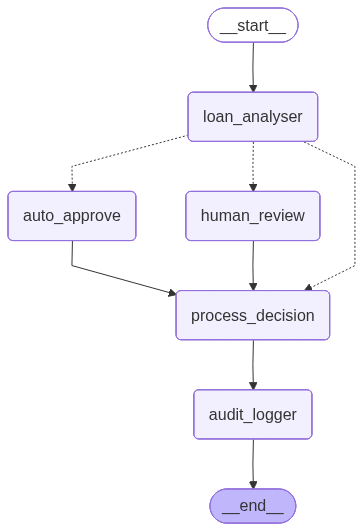

In [8]:
from IPython.display import Image, display

display(Image(loan_graph.get_graph().draw_mermaid_png()))

## Let's Test Our Loan Approval Agent!

## Test 1

In [9]:
# Process Priya's personal loan — should auto-approve
config_1 = {"configurable": {"thread_id": "loan-thread-001"}}

result = loan_graph.invoke(
    {"loan_id": "LOAN-001"},
    config_1,
)

print(f"\nFinal decision: {result.get('decision', 'N/A').upper()}")
print(f"Reviewed by   : {result.get('reviewed_by', 'N/A')}")


[Loan Analyser] Processing: LOAN-001
  Applicant    : Priya Sharma
  Loan Amount  : ₹300,000
  CIBIL Score  : 780
  DTI Ratio    : 5.9%
  Risk Level   : LOW
  Compliant    : True
  Fraud Flags  : None
  AI Recommends: APPROVE
  Needs Human  : False

[Router] ₹300,000 | Risk=LOW → AUTO-APPROVE

[Auto Approve] LOAN-001 — Auto-approved: ₹300,000 is within auto-approve limit, CIBIL 780, DTI 5.9%, risk level low.

───────────────────────────────────────────────────────
[Process Decision] LOAN-001 → APPROVED
  Applicant : Priya Sharma
  Amount    : ₹300,000
  Decision  : APPROVED
  Reason    : Auto-approved: ₹300,000 is within auto-approve limit, CIBIL 780, DTI 5.9%, risk level low.
  Reviewed  : AI
  >> Disbursement workflow triggered
───────────────────────────────────────────────────────

[Audit Logger] Full trace for LOAN-001:
  23:12:01 | loan_analyser | Risk=low | Flags=0 | Rec=approve
  23:12:01 | auto_approve | Auto-approved
  23:12:01 | process_decision | Final=approved
  Audit log

Priya's loan was **auto-approved** — no human needed. The flow was:

`START → loan_analyser → auto_approve → process_decision → audit_logger → END`

The `interrupt()` in `human_review` was **never triggered** because the AI determined it was low-risk.

## Test 2

In [10]:
# Step A: Start processing — the workflow will PAUSE at interrupt()
config_2 = {"configurable": {"thread_id": "loan-thread-002"}}

result = loan_graph.invoke(
    {"loan_id": "LOAN-002"},
    config_2,
)

print("\n>>> Workflow PAUSED — waiting for loan officer decision <<<")


[Loan Analyser] Processing: LOAN-002
  Applicant    : Rajesh Verma
  Loan Amount  : ₹5,000,000
  CIBIL Score  : 690
  DTI Ratio    : 18.0%
  Risk Level   : LOW
  Compliant    : True
  Fraud Flags  : None
  AI Recommends: APPROVE
  Needs Human  : True

[Router] ₹5,000,000 | Risk=LOW | Flags=0 → Routing to HUMAN REVIEW

*******************************************************
  LOAN OFFICER REVIEW REQUIRED — LOAN-002
*******************************************************
  loan_id               : LOAN-002
  applicant             : Rajesh Verma
  loan_amount           : ₹5,000,000
  loan_type             : business
  cibil_score           : 690
  dti_ratio             : 18.0%
  risk_level            : LOW
  fraud_flags           : None detected
  policy_compliant      : True
  ai_recommendation     : APPROVE
  ai_analysis           : JSON parse failed — defaulting to low risk.

  ACTION: Type 'approved' to approve, 'rejected: <reason>' to reject, or 'query: <your question>' to request mo

In [11]:
# Inspect the paused state — what the officer sees
paused_state = loan_graph.get_state(config_2)

print("Workflow is paused at:", paused_state.next)
print()

for task in paused_state.tasks:
    if hasattr(task, "interrupts") and task.interrupts:
        print("Review packet shown to the loan officer:")
        for k, v in task.interrupts[0].value.items():
            print(f"  {k:<22}: {v}")

Workflow is paused at: ('human_review',)

Review packet shown to the loan officer:
  loan_id               : LOAN-002
  applicant             : Rajesh Verma
  loan_amount           : ₹5,000,000
  loan_type             : business
  cibil_score           : 690
  dti_ratio             : 18.0%
  risk_level            : LOW
  fraud_flags           : None detected
  policy_compliant      : True
  ai_recommendation     : APPROVE
  ai_analysis           : JSON parse failed — defaulting to low risk.
  action_required       : Type 'approved' to approve, 'rejected: <reason>' to reject, or 'query: <your question>' to request more info


In [12]:
from langgraph.types import Command

# Step B: Officer APPROVES Rajesh's loan
result = loan_graph.invoke(
    Command(resume="approved"),
    config_2,
)

print(f"\nFinal decision: {result.get('decision', 'N/A').upper()}")
print(f"Reviewed by   : {result.get('reviewed_by', 'N/A')}")


*******************************************************
  LOAN OFFICER REVIEW REQUIRED — LOAN-002
*******************************************************
  loan_id               : LOAN-002
  applicant             : Rajesh Verma
  loan_amount           : ₹5,000,000
  loan_type             : business
  cibil_score           : 690
  dti_ratio             : 18.0%
  risk_level            : LOW
  fraud_flags           : None detected
  policy_compliant      : True
  ai_recommendation     : APPROVE
  ai_analysis           : JSON parse failed — defaulting to low risk.

  ACTION: Type 'approved' to approve, 'rejected: <reason>' to reject, or 'query: <your question>' to request more info
*******************************************************

[Human Review] Officer decision received: APPROVED

───────────────────────────────────────────────────────
[Process Decision] LOAN-002 → APPROVED
  Applicant : Rajesh Verma
  Amount    : ₹5,000,000
  Decision  : APPROVED
  Reason    : Manually approved b

## Test 3

In [13]:
# Step A: Start — will PAUSE
config_3 = {"configurable": {"thread_id": "loan-thread-003"}}

result = loan_graph.invoke(
    {"loan_id": "LOAN-003"},
    config_3,
)

print("\n>>> Workflow PAUSED — officer must review this high-risk application <<<")


[Loan Analyser] Processing: LOAN-003
  Applicant    : Anil Kumar
  Loan Amount  : ₹2,000,000
  CIBIL Score  : 540
  DTI Ratio    : 87.5%
  Risk Level   : LOW
  Compliant    : True
  Fraud Flags  : ['Low CIBIL score: 540 (min 650)', 'High DTI ratio: 88% (max 50%)', 'Vague or suspicious loan purpose']
  AI Recommends: APPROVE
  Needs Human  : True

[Router] ₹2,000,000 | Risk=LOW | Flags=3 → Routing to HUMAN REVIEW

*******************************************************
  LOAN OFFICER REVIEW REQUIRED — LOAN-003
*******************************************************
  loan_id               : LOAN-003
  applicant             : Anil Kumar
  loan_amount           : ₹2,000,000
  loan_type             : personal
  cibil_score           : 540
  dti_ratio             : 87.5%
  risk_level            : LOW
  fraud_flags           : ['Low CIBIL score: 540 (min 650)', 'High DTI ratio: 88% (max 50%)', 'Vague or suspicious loan purpose']
  policy_compliant      : True
  ai_recommendation     : APPRO

In [14]:
# Step B: Officer REJECTS with reason
result = loan_graph.invoke(
    Command(resume="rejected: CIBIL score below minimum, DTI ratio exceeds 50% limit, and loan purpose is unclear. Application cannot be processed."),
    config_3,
)

print(f"\nFinal decision: {result.get('decision', 'N/A').upper()}")
print(f"Reason        : {result.get('decision_reason', 'N/A')}")
print(f"Reviewed by   : {result.get('reviewed_by', 'N/A')}")


*******************************************************
  LOAN OFFICER REVIEW REQUIRED — LOAN-003
*******************************************************
  loan_id               : LOAN-003
  applicant             : Anil Kumar
  loan_amount           : ₹2,000,000
  loan_type             : personal
  cibil_score           : 540
  dti_ratio             : 87.5%
  risk_level            : LOW
  fraud_flags           : ['Low CIBIL score: 540 (min 650)', 'High DTI ratio: 88% (max 50%)', 'Vague or suspicious loan purpose']
  policy_compliant      : True
  ai_recommendation     : APPROVE
  ai_analysis           : JSON parse failed — defaulting to low risk.

  ACTION: Type 'approved' to approve, 'rejected: <reason>' to reject, or 'query: <your question>' to request more info
*******************************************************

[Human Review] Officer decision received: REJECTED

───────────────────────────────────────────────────────
[Process Decision] LOAN-003 → REJECTED
  Applicant : Anil K

## Test 4

In [15]:
# Step A: Start — will PAUSE
config_4 = {"configurable": {"thread_id": "loan-thread-004"}}

result = loan_graph.invoke(
    {"loan_id": "LOAN-004"},
    config_4,
)

print("\n>>> Workflow PAUSED — officer reviewing <<<")


[Loan Analyser] Processing: LOAN-004
  Applicant    : Meena Patel
  Loan Amount  : ₹800,000
  CIBIL Score  : 740
  DTI Ratio    : 13.3%
  Risk Level   : LOW
  Compliant    : True
  Fraud Flags  : None
  AI Recommends: APPROVE
  Needs Human  : True

[Router] ₹800,000 | Risk=LOW | Flags=0 → Routing to HUMAN REVIEW

*******************************************************
  LOAN OFFICER REVIEW REQUIRED — LOAN-004
*******************************************************
  loan_id               : LOAN-004
  applicant             : Meena Patel
  loan_amount           : ₹800,000
  loan_type             : home
  cibil_score           : 740
  dti_ratio             : 13.3%
  risk_level            : LOW
  fraud_flags           : None detected
  policy_compliant      : True
  ai_recommendation     : APPROVE
  ai_analysis           : JSON parse failed — defaulting to low risk.

  ACTION: Type 'approved' to approve, 'rejected: <reason>' to reject, or 'query: <your question>' to request more info
****

In [16]:
# Step B: Officer raises a query
result = loan_graph.invoke(
    Command(resume="query: Please provide latest 6-month bank statements and property valuation certificate before proceeding."),
    config_4,
)

print(f"\nFinal decision: {result.get('decision', 'N/A').upper()}")
print(f"Reason        : {result.get('decision_reason', 'N/A')}")


*******************************************************
  LOAN OFFICER REVIEW REQUIRED — LOAN-004
*******************************************************
  loan_id               : LOAN-004
  applicant             : Meena Patel
  loan_amount           : ₹800,000
  loan_type             : home
  cibil_score           : 740
  dti_ratio             : 13.3%
  risk_level            : LOW
  fraud_flags           : None detected
  policy_compliant      : True
  ai_recommendation     : APPROVE
  ai_analysis           : JSON parse failed — defaulting to low risk.

  ACTION: Type 'approved' to approve, 'rejected: <reason>' to reject, or 'query: <your question>' to request more info
*******************************************************

[Human Review] Officer decision received: PENDING_QUERY

───────────────────────────────────────────────────────
[Process Decision] LOAN-004 → PENDING_QUERY
  Applicant : Meena Patel
  Amount    : ₹800,000
  Decision  : PENDING_QUERY
  Reason    : Officer raised

In [17]:
# Inspect final state of Rajesh's business loan
final_state = loan_graph.get_state(config_2)

print("Final state — LOAN-002 (Rajesh Verma's business loan):")
print()
for key, value in final_state.values.items():
    if key == "audit_log":
        print(f"  {key}:")
        for entry in value:
            print(f"    {entry}")
    else:
        print(f"  {key:<25}: {value}")

print(f"\nWorkflow completed: {final_state.next == ()}")

Final state — LOAN-002 (Rajesh Verma's business loan):

  loan_id                  : LOAN-002
  applicant                : Rajesh Verma
  loan_amount              : 5000000
  loan_type                : business
  cibil_score              : 690
  dti_ratio                : 0.18
  fraud_flags              : []
  policy_compliant         : True
  risk_level               : low
  ai_recommendation        : approve
  ai_analysis_summary      : JSON parse failed — defaulting to low risk.
  needs_human_review       : True
  decision                 : approved
  decision_reason          : Manually approved by loan officer after review.
  reviewed_by              : Loan Officer
  audit_log:
    23:13:09 | loan_analyser | Risk=low | Flags=0 | Rec=approve
    23:13:25 | human_review | Officer decision: approved | Manually approved by loan officer after review.
    23:13:25 | process_decision | Final=approved

Workflow completed: True
